# Gerekli Kütüphaneler:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
random.seed(101)
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import tensorflow
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization, Conv2D, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2


C:\Users\Asus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Veri Ön Hazırlık:

In [2]:
# veri setini yükleme
Data_DIR = "Chest X_Ray Dataset"

# sınıf etiketleri
clinical_labels = ["COVID19", "NORMAL", "PNEUMONIA", "TUBERCULOSIS"]

# görüntüleri ve ilgili etiketleri sırayla toplama
X_Images = []
Y_Labels = []
# max, min yükseklik & genişlik
max_weidth = float('-inf')
min_weidth = float('inf')
max_height = float('-inf')
min_height = float('inf')
# max ve min pixel
max_pixel = float('-inf')
min_pixel = float('inf')

for lab in clinical_labels:
    # folder path (TURBERCULOSIS hatası düzeltildi, klasör yeniden adlandırıldıysa direkt lab kullanılır)
    folder_path = os.path.join(Data_DIR, lab)
    if not os.path.exists(folder_path):
        # Eğer henüz isim değiştirilmediyse eski ismi dene
        if lab == "TUBERCULOSIS" and os.path.exists(os.path.join(Data_DIR, "TURBERCULOSIS")):
            folder_path = os.path.join(Data_DIR, "TURBERCULOSIS")
        else:
            continue
            
    for img in os.listdir(folder_path):
        # görüntülerin yüklenmesi
        img_path = os.path.join(folder_path, img)
        # görüntülerin okunması
        image = cv2.imread(img_path)
        
        # None kontrolü eklendi (Hata düzeltmesi)
        if image is not None:
            image = cv2.resize(image, (224,224)) # dönüştürme
            
            # min,max pixellerin güncelleştirilmesi
            max_pixel = max(max_pixel, image.max())
            min_pixel = min(min_pixel, image.min())

            # yükseklik ve genişliğin güncelleştirilmesi
            max_height = max(max_height, image.shape[0])
            min_height = min(min_height, image.shape[0])

            max_weidth = max(max_weidth, image.shape[1])
            min_weidth = min(min_weidth, image.shape[1])

            # görüntü ve etiket listesini güncelleme
            X_Images.append(image)
            Y_Labels.append(lab)
        else:
            print(f"geçersiz görüntü bozuk dosya atlandı: {img_path}")

print("veriler başarıyla yüklendi...")

veriler başarıyla yüklendi...


In [3]:
# piksel bilgilerini yazdırma
print(f'maximum pixel değeri: {max_pixel}')
print(f'minimum pixel değeri: {min_pixel}')

# görüntülerin yükseklik ve genişlik bilgilerini yazdırma
print(f'\nmaximum yükseklik değeri: {max_height}')
print(f'minimum yükseklik değeri: {min_height}')

print(f'\nmaximum genişlik değeri: {max_weidth}')
print(f'minimum genişlik değeri: {min_weidth}')

maximum pixel değeri: 255
minimum pixel değeri: 0

maximum yükseklik değeri: 224
minimum yükseklik değeri: 224

maximum genişlik değeri: 224
minimum genişlik değeri: 224


In [4]:
# Toplam örnek sayısı
num_sample = len(X_Images)
print(f"toplam örnek sayısı:{num_sample}")

toplam örnek sayısı:7132


# Bazı Görüntüleri Görselleştirme:

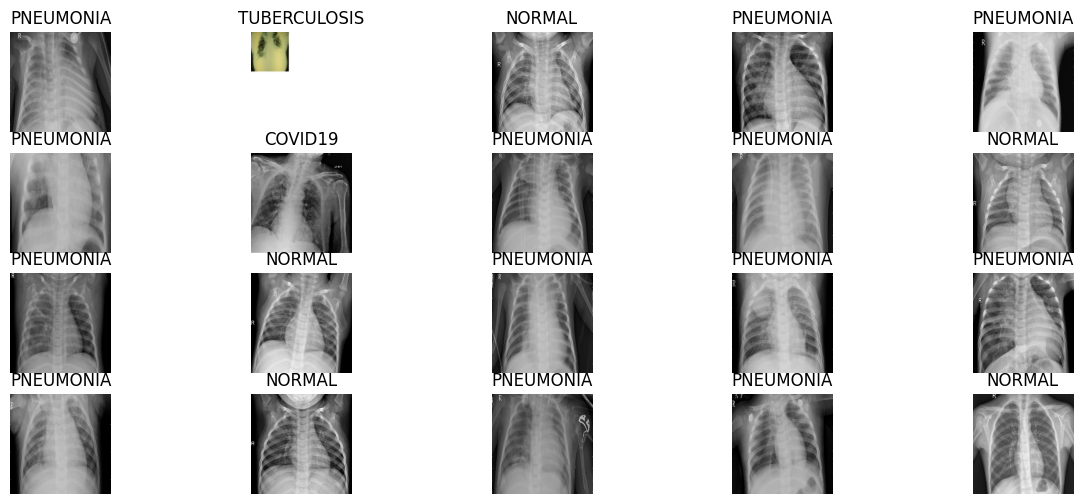

In [5]:
# resim sayısı
num_img = 20
plt.figure(figsize=(15,6))
# rasgele örnek çekme
random_idx = random.sample(range(num_sample),num_img)
for i in range(num_img):
    plt.subplot(num_img//5,5,i+1) 
    plt.imshow(X_Images[random_idx[i]], cmap='gray')
    plt.axis('off')
    plt.title(f"{Y_Labels[random_idx[i]]}")
plt.show()

# Görüntü Ön işleme:

### White Balance Yaklaşımı:

**White balance** özellikle COVID-19, zatürre, tüberküloz ve diğer viral enfeksiyonların teşhisi için göğüs röntgenlerini (CXR) analiz ederken tıbbi görüntülemede çok önemli bir rol oynar. Tıbbi görüntülemede amaç genellikle görüntünün temel özelliklerini (akciğerler ve çevresindeki dokular gibi) görüntünün geri kalanından açıkça ayırt edilebilir hale getirmektir.

**Akciğerler** tipik olarak siyah (veya çok koyu) görünürler çünkü hava doludurlar ve kemikler ve kaslar gibi çevre dokulara kıyasla daha az X-ışını emerler. Karanlık alanlar düşük yoğunluklu yapıları temsil eder ve bu, akciğerlerin göğüs röntgeninde görüntülenmesi için önemlidir.

**Kemikler, organlar ve dokular**, ise daha fazla X-ışını emdikleri için beyaz veya açık gri görünürler ve bu da görüntüde daha yüksek bir yoğunluğa yol açar. 
Akciğerlerin görselliğini iyileştirmek için beyaz dengesi uygulayacağız:

In [6]:
# her kanal için white balace
def WB_channel(channel, perc=0.05):
    mi, ma = (np.percentile(channel, perc), np.percentile(channel, 100-perc))
    channel = np.uint8(np.clip((channel-mi)*255.0/(ma-mi), 0, 255))
    return channel
# bir görüntüye white balance
def WB_image(img):
    img = img.copy()
    imwb = np.dstack([WB_channel(channel, 0.05) for channel in cv2.split(img)]) # bu renkli wb görüntüsü
    imwb_gray = cv2.cvtColor(imwb, cv2.COLOR_BGR2GRAY) # bu da BGR formatında orijinal görüntü olarak
    # gri ve renkli görüntüyü döndürme
    return imwb_gray, imwb

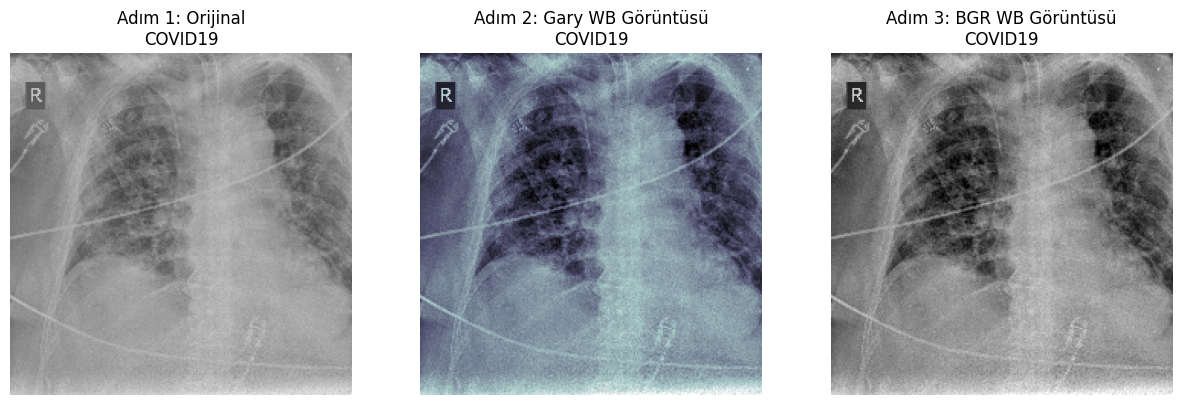

In [7]:
#deneme
img = X_Images[0]
imgwb_gray, imwb_BGR = WB_image(img)
plt.figure(figsize=(15,6))
plt.subplot(131)
plt.imshow(img, cmap='bone')
plt.title(f"Adım 1: Orijinal\n{Y_Labels[0]}")
plt.axis('off')
plt.subplot(132)
plt.imshow(imgwb_gray, cmap="bone")
plt.title(f"Adım 2: Gary WB Görüntüsü\n{Y_Labels[0]}")
plt.axis('off')
plt.subplot(133)
plt.imshow(imwb_BGR, cmap="bone")
plt.title(f"Adım 3: BGR WB Görüntüsü\n{Y_Labels[0]}")
plt.axis('off')
plt.show()

white balace filtreli görüntüyü hem gri hem de BGR formatında görselleştirdik.

In [8]:
# tüm görüntülere White balance uygulama
X_imwb = []
for img in X_Images:
    
    _, imwb_BGR = WB_image(img) 
    X_imwb.append(imwb_BGR)
    
print("WB yapıldı...")

WB yapıldı...


# Filtrelenmiş Görüntüleri Görselleştirme:

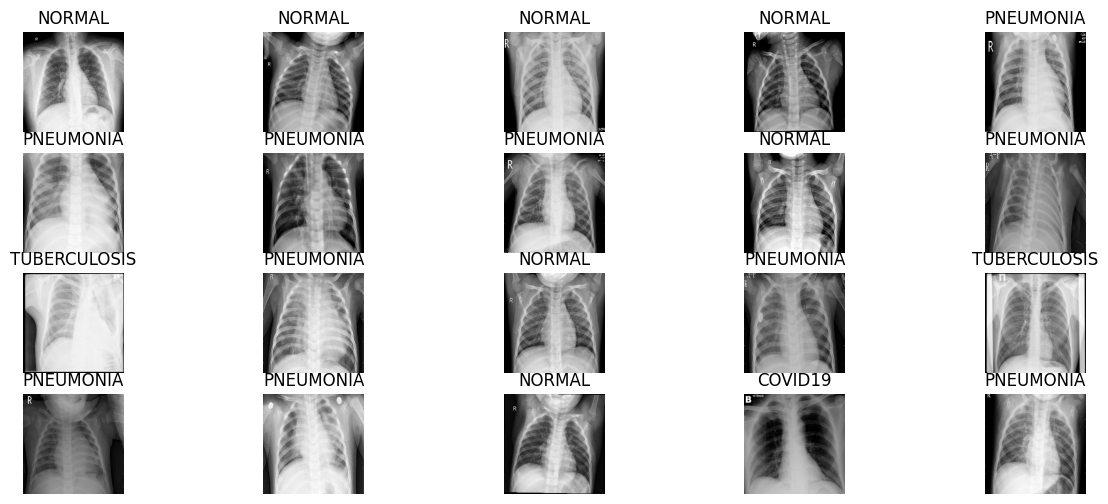

In [9]:
# WB görüntülerini gösterme
num_img = 20
plt.figure(figsize=(15,6))
# rasgele örnekler
random_idx = random.sample(range(num_sample),num_img)
for i in range(num_img):
    plt.subplot(num_img//5,5,i+1) 
    plt.imshow(X_imwb[random_idx[i]], cmap='gray')
    plt.axis('off')
    plt.title(f"{Y_Labels[random_idx[i]]}")
plt.show()

# Görüntü Normalleştirme:

In [10]:
X_imwb_norm = []
for img in X_imwb:
    img_norm = (img/255.0).astype('float32') #her görüntüdeki her piksel aralığının [0,1] olması.
    X_imwb_norm.append(img_norm)
print('Normalize yapıldı....')

Normalize yapıldı....


# Sınıf Dağılımı:

In [11]:
# tüm listeyi np dizisine dönüştürme
X_imwb_norm = np.array(X_imwb_norm)
Y_labels = np.array(Y_Labels)

In [12]:
# Her tümör türü için adet sayısı:
pd.DataFrame(list(Counter(Y_labels).items()), columns=['Class', 'Count'])

,Class,Count
0,COVID19,576
1,NORMAL,1583
2,PNEUMONIA,4273
3,TUBERCULOSIS,700


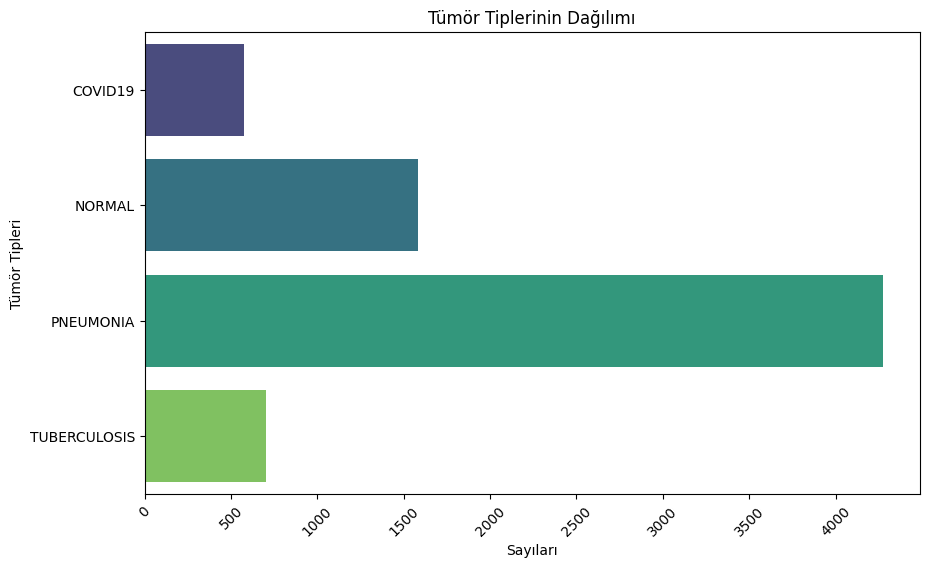

In [13]:
#Tümör Tiplerinin Dağılımı
plt.figure(figsize=(10, 6))
sns.countplot(y=Y_labels, palette='viridis')  
plt.xticks(rotation=45) 
plt.xlabel('Sayıları')  
plt.ylabel('Tümör Tipleri')  
plt.title('Tümör Tiplerinin Dağılımı') 
plt.show()


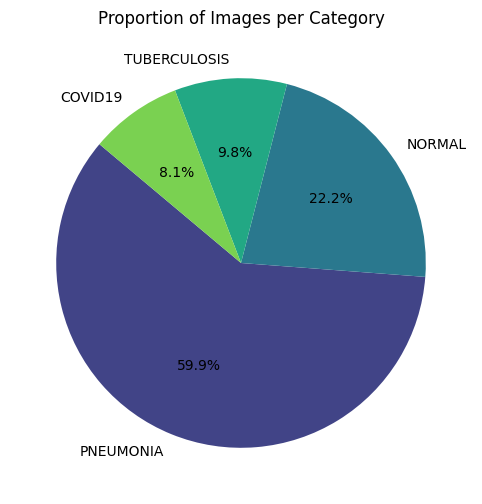

In [20]:
#pasta dağılımları:
# Tümör etiketlerinin sayısını alıyoruz
category_counts = pd.Series(Y_labels).value_counts()  # Y_labels kategori etiketlerini sayıyoruz

# Pasta grafiği çizme
plt.figure(figsize=(8, 6))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(category_counts)))
plt.title("Proportion of Images per Category")
plt.show()


#  stratified splitting ile tüm veri setini rastgele olarak train ve teste bölme:

**Stratified** splitting veri kümemizdeki sınıf dağılımının eğitim ve test kümeleri arasında korunmasını sağlar. Bu, özellikle dengesiz veri kümeleri için, model değerlendirmesi sırasında belirli sınıfların aşırı temsil edilmesini veya yetersiz temsil edilmesini önlemek için önemlidir. Bölünme, etiketler (hedef değişken) temel alınarak gerçekleştirilir, böylece orijinal veri kümesindeki her sınıfın oranı hem eğitim hem de test kümelerinde yansıtılır. Python’da bu, **train_test_split** ’te **stratify** kullanılarak uygulanabilir. Sınıf dengesinin korunmasının çok önemli olduğu sınıflandırma problemlerinde özellikle kullanışlıdır.

In [28]:
#stratified splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_imwb_norm, Y_labels, test_size=0.2, stratify=Y_labels, random_state=42
)

print('veriler 80-20 olarak bölündü!..')

veriler 80-20 olarak bölündü!..


,Class,Count
0,PNEUMONIA,3418
1,TUBERCULOSIS,560
2,NORMAL,1266
3,COVID19,461


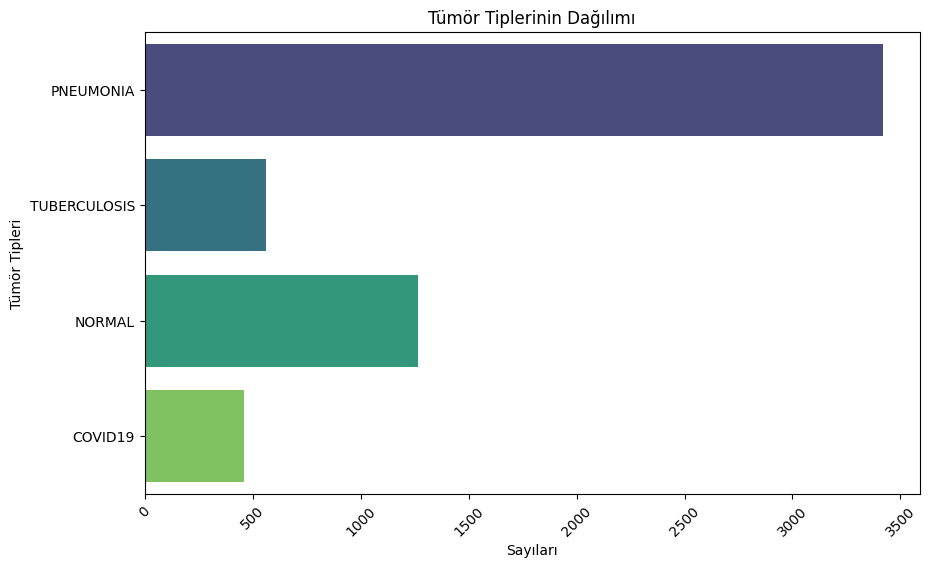

In [30]:
# eğitim setinde sınıf dağılımı
display(pd.DataFrame(list(Counter( y_train).items()), columns=['Class', 'Count']))

# Çubuk grafikler
plt.figure(figsize=(10, 6))
sns.countplot(y= y_train, palette='viridis')  
plt.xticks(rotation=45)  
plt.xlabel('Sayıları')  
plt.ylabel('Tümör Tipleri')  
plt.title('Tümör Tiplerinin Dağılımı')  
plt.show()

# kategorik etiketleri sayısal değerlere & one-hot gösterime dönüştürme:

In [31]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Encoded başarıyla yapıldı!")

Encoded başarıyla yapıldı!


In [32]:
# orijinal etiketlerin Encoded etiketlere eşlemesini alma.
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Etiket eşlemesi:", label_mapping)

Etiket eşlemesi: {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TUBERCULOSIS': 3}


In [33]:
# tamsayı etiketini One-hot'a dönüştürme
y_train_one_hot = to_categorical(y_train_encoded, num_classes=len(label_encoder.classes_))
y_test_one_hot = to_categorical(y_test_encoded, num_classes=len(label_encoder.classes_))

print("One-hot dönüşümü yapıldı!")

One-hot dönüşümü yapıldı!


In [34]:
print(f"Önceden Encoding: {y_test}")
print(f"Sonradan Encoding: {y_test_encoded}")
print(f"Sonradan one-hot dönüşümleri: {y_test_one_hot}")

Önceden Encoding: ['NORMAL' 'PNEUMONIA' 'PNEUMONIA' ... 'PNEUMONIA' 'PNEUMONIA' 'PNEUMONIA']
Sonradan Encoding: [1 2 2 ... 2 2 2]
Sonradan one-hot dönüşümleri: [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]]


In [36]:
# tüm setlerin aynı formatta olduğundan emin olma.
print('Train görüntüsü: ', type(X_train))
print('Train etiketi: ', type(y_train_one_hot))
print('Test görüntüsü: ',  type(X_test))
print('Test etiketi: ', type(y_test_one_hot))

Train görüntüsü:  <class 'numpy.ndarray'>
Train etiketi:  <class 'numpy.ndarray'>
Test görüntüsü:  <class 'numpy.ndarray'>
Test etiketi:  <class 'numpy.ndarray'>


In [ ]:
# MODEL OLUŞTURMA (MobileNetV2 ile Transfer Learning)
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Önceden eğitilmiş MobileNetV2 modelini yükleme (üst kısımlarını hariç tutarak)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # İlk başta donduruyoruz

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(clinical_labels), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Modeli derleme
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()


In [ ]:
# VERİ ARTIRMA VE EĞİTİM (Data Augmentation)
# Veri boyutunu şekillendirme (None, 224, 224, 3) 
# Griwb görüntüler BGR yapıldığı için 3 kanallı formattalar
X_train_shaped = X_train.reshape(-1, 224, 224, 3)
X_test_shaped = X_test.reshape(-1, 224, 224, 3)

# Data augmentation tanımlama
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Class Weights (Sınıf dengesizliğini çözmek için)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights_dict = dict(enumerate(class_weights))
print("Sınıf Ağırlıkları:", class_weights_dict)


In [ ]:
# Callback'ler (Eğitimi İzleme ve Erken Durdurma)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('Best_Model_On_Partial.keras', save_best_only=True, monitor='val_loss', mode='min')
]

# Modeli Eğitme
history = model.fit(
    datagen.flow(X_train_shaped, y_train_one_hot, batch_size=32),
    validation_data=(X_test_shaped, y_test_one_hot),
    epochs=20, # İsteğe göre artırılabilir
    class_weight=class_weights_dict,
    callbacks=callbacks
)


In [ ]:
# EĞİTİM SONUÇLARINI GÖRSELLEŞTİRME
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Model Doğruluğu')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Model Kaybı')
plt.legend()
plt.show()


In [ ]:
# MODEL DEĞERLENDİRMESİ
# Sınıflandırma raporu
y_pred = model.predict(X_test_shaped)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Sınıflandırma Raporu:")
print(classification_report(y_test_encoded, y_pred_classes, target_names=label_encoder.classes_))

# Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_test_encoded, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.title('Karmaşıklık Matrisi')
plt.show()
